In [1]:
import os

base_path = r'C:\Users\Admin\OneDrive\Desktop\CNN\plantvillage'

for item in os.listdir(base_path):
    item_path = os.path.join(base_path, item)
    if os.path.isdir(item_path):
        num_images = len(os.listdir(item_path))
        print(f"{item}/ — {num_images} images")

Pepper__bell___Bacterial_spot/ — 978 images
Pepper__bell___healthy/ — 1478 images
Potato___Early_blight/ — 1000 images
Potato___healthy/ — 152 images
Potato___Late_blight/ — 1000 images
Tomato_Bacterial_spot/ — 2127 images
Tomato_Early_blight/ — 1000 images
Tomato_healthy/ — 1591 images
Tomato_Late_blight/ — 1909 images
Tomato_Leaf_Mold/ — 952 images
Tomato_Septoria_leaf_spot/ — 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite/ — 1676 images
Tomato__Target_Spot/ — 1404 images
Tomato__Tomato_mosaic_virus/ — 373 images
Tomato__Tomato_YellowLeaf__Curl_Virus/ — 3209 images


In [2]:
import os
import shutil

rogue = r'C:\Users\Admin\OneDrive\Desktop\CNN\plantvillage'
print(os.listdir(rogue))  # check what's inside first

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [3]:
import tensorflow as tf

base_path = r'C:\Users\Admin\OneDrive\Desktop\CNN\plantvillage'

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print(f"Total classes: {len(class_names)}")
print(class_names)

Found 20619 files belonging to 15 classes.
Using 16496 files for training.
Found 20619 files belonging to 15 classes.
Using 4123 files for validation.
Total classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


Image batch shape: (32, 224, 224, 3)
Pixel range: 0 to 254
Dtype: <dtype: 'float32'>


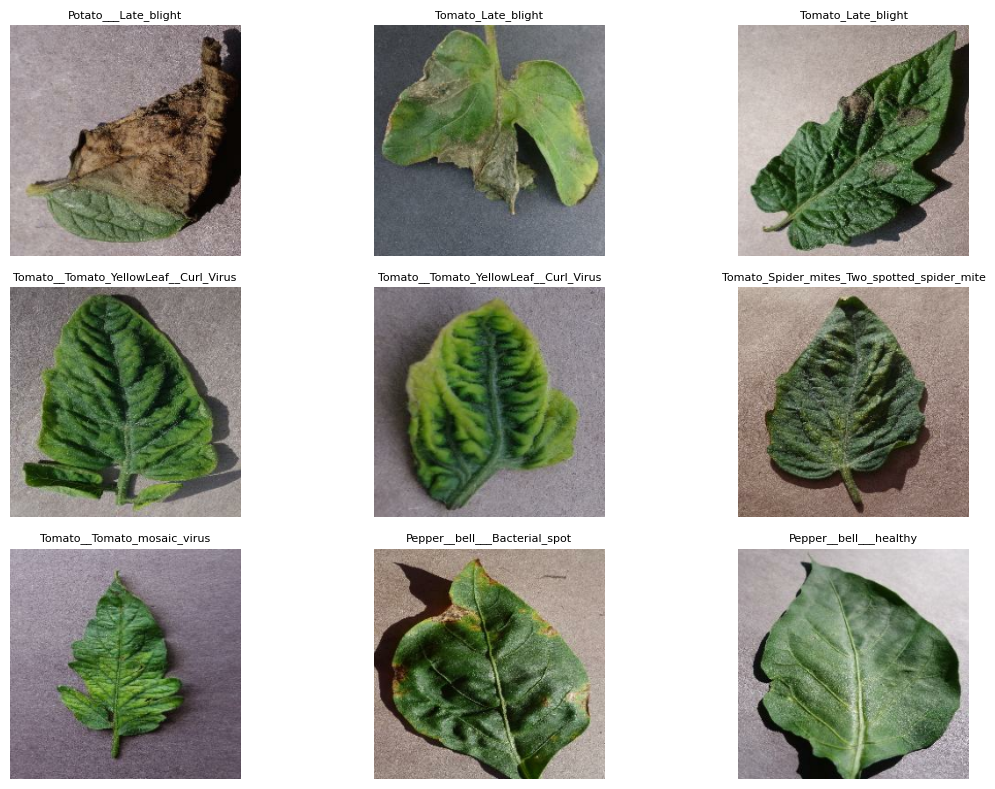

In [4]:
import matplotlib.pyplot as plt

# check pixel range
for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Pixel range: {images.numpy().min():.0f} to {images.numpy().max():.0f}")
    print(f"Dtype: {images.dtype}")

# visualize
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=8)
        plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf

base_path = r'C:\Users\Admin\OneDrive\Desktop\CNN\plantvillage'
AUTOTUNE = tf.data.AUTOTUNE

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name='augmentation')

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names

train_ds = (train_ds
    .map(lambda x, y: (augment(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .shuffle(500)
    .prefetch(AUTOTUNE)
)

val_ds = val_ds.prefetch(AUTOTUNE)

print(f"Classes: {len(class_names)}")
print(class_names)

Found 20619 files belonging to 15 classes.
Using 16496 files for training.
Found 20619 files belonging to 15 classes.
Using 4123 files for validation.
Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [6]:
#Model bulding

base_model = tf.keras.applications.EfficientNetB0(
    weights = "imagenet",
    include_top = False,
    input_shape = (224,224,3)
)

base_model.trainable  = False

inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs , training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(15, activation = "softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 15)                  │          19,215 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=r'C:\Users\Admin\OneDrive\Desktop\CNN\best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 617s 998ms/step - accuracy: 0.7423 - loss: 0.9422 - val_accuracy: 0.8528 - val_loss: 0.5222
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.8731 - loss: 0.4580 - val_accuracy: 0.8896 - val_loss: 0.3794
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 561s 961ms/step - accuracy: 0.8967 - loss: 0.3654 - val_accuracy: 0.9015 - val_loss: 0.3250
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 541s 925ms/step - accuracy: 0.9105 - loss: 0.3089 - val_accuracy: 0.9154 - val_loss: 0.2835
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 611s 1s/step - accuracy: 0.9185 - loss: 0.2800 - val_accuracy: 0.9158 - val_loss: 0.2648
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 592s 1s/step - accuracy: 0.9214 - loss: 0.2580 - val_accuracy: 0.9304 - val_loss: 0.2291
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 589s 1s/step - accuracy: 0.9248 - loss: 0.2448 - val_accuracy: 0.9316 - val_loss: 0.2162
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 560s 948ms/step - accuracy: 0.9303 - loss: 0.229

In [11]:
#Model saved
model.save(r'C:\Users\Admin\OneDrive\Desktop\CNN\best_model.keras')
print("Saved")

Saved


In [13]:
#Load the best model

model = tf.keras.models.load_model(
        r'C:\Users\Admin\OneDrive\Desktop\CNN\best_model.keras'
)

#Evaluate best accuracy and loss

loss, accuracy = model.evaluate(val_ds)
print(f"Validation accuracy : {accuracy:.4f}")
print(f"Validation loss : {loss:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 95s 704ms/step - accuracy: 0.9309 - loss: 0.2126
Validation accuracy : 0.9309
Validation loss : 0.2126


C:\Users\Admin\AppData\Local\Temp\ipykernel_12548\2096280549.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


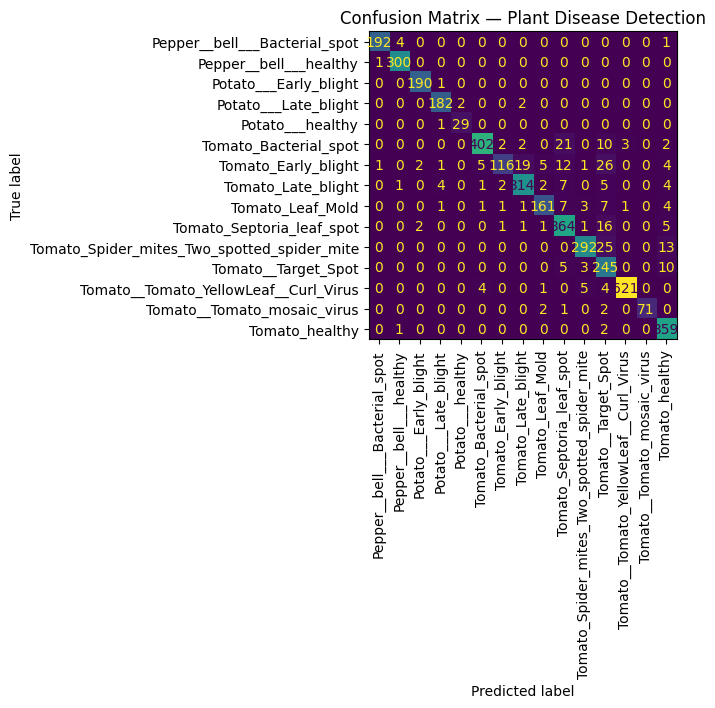

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import *

y_true = []
y_pred = []

for images , lables in val_ds:
    pred = model.predict(images, verbose = 0)
    y_true.extend(lables.numpy())
    y_pred.extend(np.argmax(pred , axis =1))

cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels = class_names)

fig,ax = plt.subplots(figsize=(14,4))
disp.plot(ax=ax, xticks_rotation = 90, colorbar = False)
plt.title('Confusion Matrix — Plant Disease Detection')
plt.tight_layout()
plt.show()

In [20]:
#See every calss accuravy
per_class = cm.diagonal() / cm.sum(axis=1)
for name, acc in zip(class_names, per_class):
    print(f"{acc:.2f}  {name}")

0.97  Pepper__bell___Bacterial_spot
1.00  Pepper__bell___healthy
0.99  Potato___Early_blight
0.98  Potato___Late_blight
0.97  Potato___healthy
0.91  Tomato_Bacterial_spot
0.60  Tomato_Early_blight
0.92  Tomato_Late_blight
0.86  Tomato_Leaf_Mold
0.93  Tomato_Septoria_leaf_spot
0.88  Tomato_Spider_mites_Two_spotted_spider_mite
0.93  Tomato__Target_Spot
0.98  Tomato__Tomato_YellowLeaf__Curl_Virus
0.93  Tomato__Tomato_mosaic_virus
0.99  Tomato_healthy
